# Does a neural network know which paintings you will remember?
**Reading:** Davis, T. M., & Bainbridge, W. A. (2023). Memory for artwork is predictable. *PNAS, 120*(28), e2302389120.

**What you will do**
1. Load the paintings and human memorability scores
2. Guess which paintings are memorable yourself
3. Let ResMem predict memorability
4. Correlate ResMem with humans
5. Look at where ResMem and humans disagree

## Setup

In [1]:
%pip install -q resmem
import warnings; warnings.filterwarnings("ignore")
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from PIL import Image
import torch
from resmem import ResMem, transformer
import os, zipfile
from pathlib import Path
device = "cpu"

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Find the course data in Sciebo (works even if the shared folder was renamed)
matches = list(Path.home().glob("sciebo/*/Week0/"))
if not matches:
    raise FileNotFoundError(
        "Course data not found. Did you connect Sciebo when starting the server, "
        "and accept the shared CNU folder in Sciebo?"
    )
DATA = matches[0]
SCORES_FILE = DATA / "art_memorability.csv"
IMAGE_DIR = DATA / "art_images"

## 1. Load the paintings and the human memory scores
Each row is one painting. `human_memorability` is how well people remembered it in the online experiment. It is the **corrected recognition** score: the proportion of people who recognised the painting when it repeated (hits), minus the proportion who wrongly claimed to have seen it before (false alarms).

In [3]:
# Load behavioral data
all_data = pd.read_csv(SCORES_FILE)
print(f"Using data from {DATA}")
print(f"{len(all_data)} paintings available")

Using data from /home/e/eilkel/sciebo/CNU/Week0
500 paintings available


In [27]:
# --- Choose which paintings to use -------------------------------------
N_PAINTINGS = 100    # how many paintings to use today (more = slower, but more reliable)
SEED = 1             # change this to get a different random subset

# Randomly pick N_PAINTINGS rows from the full table.
# min(...) makes sure we never ask for more paintings than exist.
# random_state=SEED makes the selection reproducible: same seed, same paintings.
# reset_index(drop=True) renumbers the rows 0, 1, 2, ... after sampling.
data = all_data.sample(n=min(N_PAINTINGS, len(all_data)), random_state=SEED).reset_index(drop=True)

# --- Load the images ----------------------------------------------------
images = []                                   # start with an empty list
for filename in data["filename"]:             # go through the filenames one by one
    path = IMAGE_DIR / filename               # build the full path to the image on Sciebo
    img = Image.open(path).convert("RGB")     # open it; convert("RGB") ensures 3 color channels
    images.append(img)                        # add the image to our list

# --- Check the result ---------------------------------------------------
print(f"Using {len(data)} paintings")
data.head()                                   # show the first 5 rows of the table

Using 100 paintings


,filename,aic_id,title,artist,human_memorability,resmem_paper
0,97884.jpg,97884,"A Glimpse into Hell, or Fear",Elihu Vedder,0.558,0.782026
1,74034.jpg,74034,Baptismal Certificate of Catharina Wentzelsin,NaN,0.751,0.874147
2,131822.jpg,131822,"Four Princes in Procession Visit a Sage, page ...",NaN,0.425,0.640977
3,26684.jpg,26684,La Piana,Edward Lear,0.439,0.587517
4,16584.jpg,16584,"Houses of Parliament, London",Claude Monet,0.750,0.605454


## 2. Your turn first: which of these will people remember?

Below are  random paintings. **Before running the next cell**, rank them from most to least memorable and write your ranking down. Compare with your neighbour: do you agree?

In [28]:
def show_grid(df, images, label_cols, sort_by=None, n_cols=5, title=None):
    """Show paintings in a grid with selected columns written underneath.
    df must come from `data`, so that row index i matches images[i]."""

    # Optionally sort the paintings (lowest to highest value)
    if sort_by is not None:
        df = df.sort_values(sort_by)

    # Create enough rows of plots for all paintings
    n_rows = int(np.ceil(len(df) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(2.6 * n_cols, 3 * n_rows))
    axes = np.atleast_1d(axes).ravel()          # turn the grid into a simple list

    # Hide axis ticks on every plot (also the empty ones at the end)
    for ax in axes:
        ax.axis("off")

    # Draw one painting per plot, with its labels underneath
    plot_number = 0
    for idx, row in df.iterrows():
        ax = axes[plot_number]
        ax.imshow(images[idx])                  # row index idx matches images[idx]

        lines = []
        for column in label_cols:
            value = row[column]
            if isinstance(value, float):
                lines.append(f"{column}: {value:.2f}")   # numbers: 2 decimals
            else:
                lines.append(str(value)[:25])            # text: first 25 characters
        ax.set_title("\n".join(lines), fontsize=8)

        plot_number = plot_number + 1

    # Optional title for the whole figure
    if title is not None:
        fig.suptitle(title, fontsize=13)

    plt.tight_layout()
    plt.show()

In [29]:
n_image = 10      # number of images to display
random_s = 11     # change this to see different images


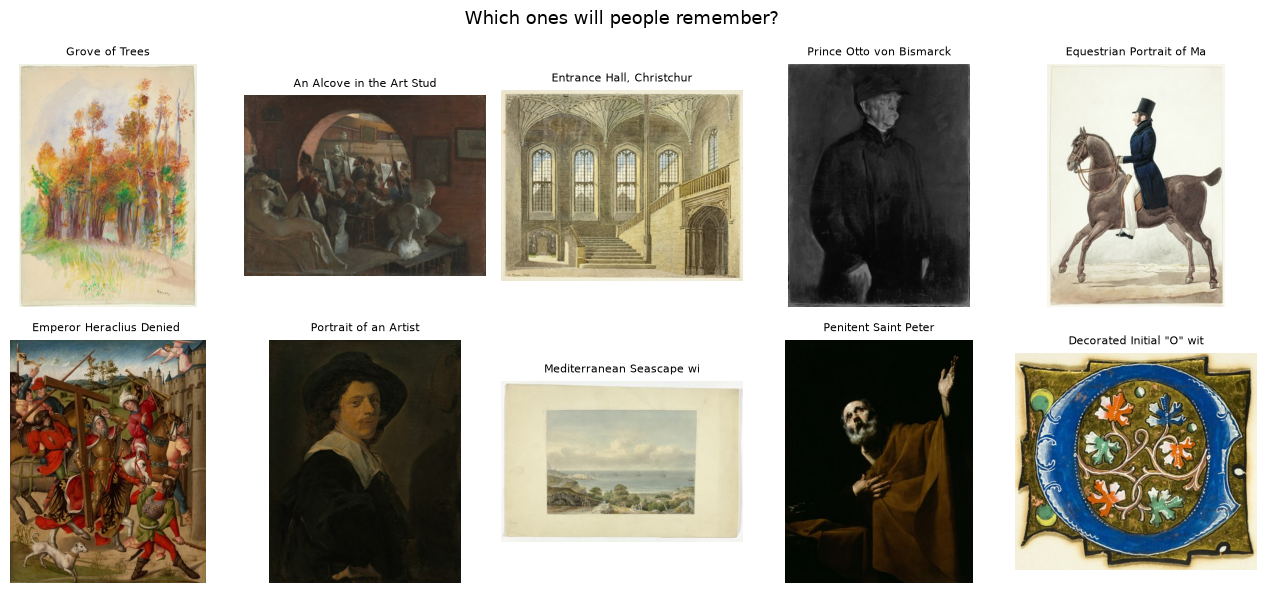

In [30]:
guess_set = data.sample(n_image, random_state=random_s)
show_grid(guess_set, images, label_cols=["title"], title="Which ones will people remember?")

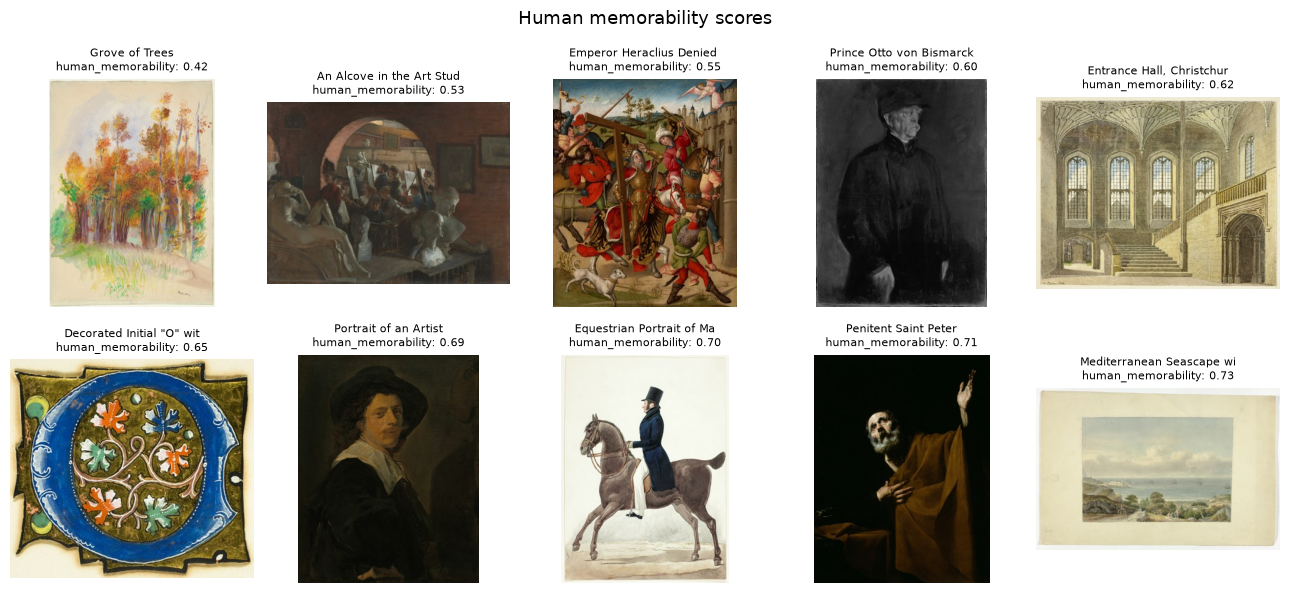

In [31]:
# Reveal the human scores
show_grid(guess_set, images, label_cols=["title", "human_memorability"], title="Human memorability scores",sort_by="human_memorability")

## 3. Let ResMem predict memorability

ResMem was trained on everyday photographs (the LaMem and MemCat datasets), **not on art**. It has never seen these paintings or any human data about them.

In [32]:
# Load ResMem with its trained weights (pretrained=True),
# and switch it to evaluation mode (.eval()), which turns off
# training-only behaviour such as dropout, so predictions are stable

model = ResMem(pretrained=True).to(device).eval()

def predict_memorability(imgs, batch_size=32):
    """Return ResMem's memorability prediction for each image in `imgs`."""
    scores = []

    # We only make predictions and don't train the model,
    # so PyTorch doesn't need to track gradients. This saves memory and time.
    with torch.no_grad():

        # Process the images in batches of `batch_size` (here 32) at a time,
        # which is much faster than one by one
        for i in range(0, len(imgs), batch_size):

            # Prepare each image the way ResMem expects it: `transformer`
            # resizes and crops it to 227 x 227 pixels and turns it into a tensor
            # (PyTorch's array format). torch.stack combines the images into one
            # batch, and .to(device) moves it to the same device as the model.
            batch = torch.stack([transformer(img) for img in imgs[i:i + batch_size]]).to(device)

            # Run the batch through the network. The output has shape (batch_size, 1):
            # .squeeze(1) turns it into a flat list of scores, .cpu() moves it back
            # from the GPU, and .numpy() converts it to a normal numpy array.
            scores.extend(model(batch).squeeze(1).cpu().numpy())

    return np.array(scores)

# Predict memorability for all paintings and store it as a new column
data["resmem"] = predict_memorability(images)

# Show the first few rows: human scores next to ResMem's predictions
data[["title", "human_memorability", "resmem"]].head()

,title,human_memorability,resmem
0,"A Glimpse into Hell, or Fear",0.558,0.763156
1,Baptismal Certificate of Catharina Wentzelsin,0.751,0.862490
2,"Four Princes in Procession Visit a Sage, page ...",0.425,0.645114
3,La Piana,0.439,0.606191
4,"Houses of Parliament, London",0.750,0.632167


How did ResMem do on the paintings you ranked? Did it agree more with you or with the humans?

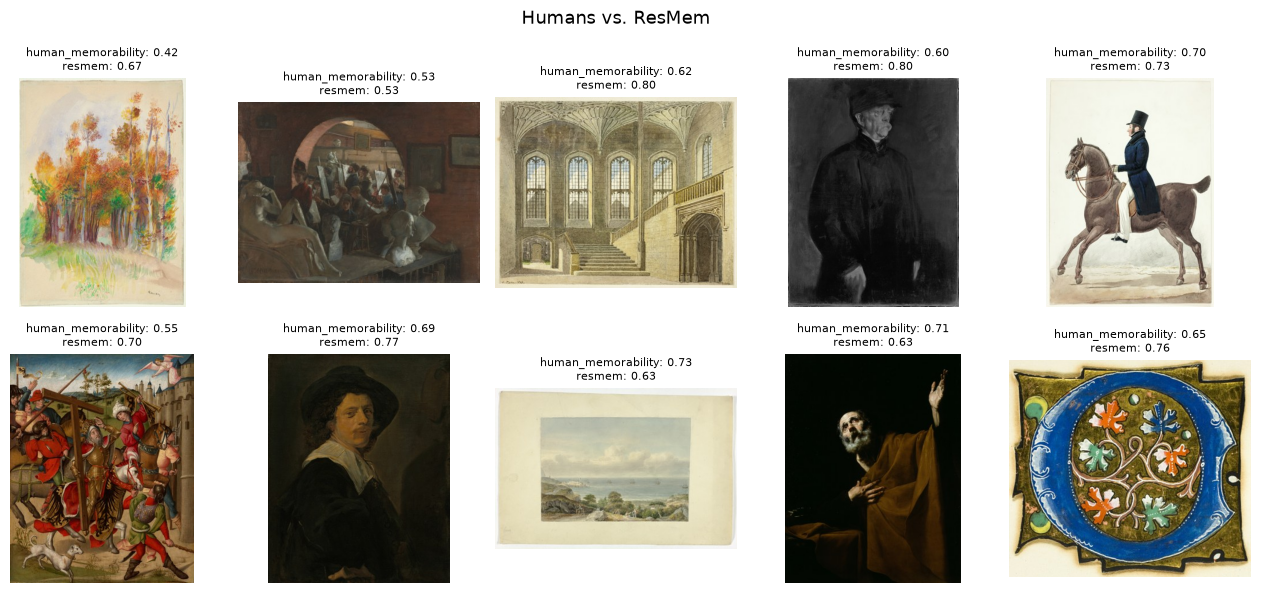

In [33]:
show_grid(data.loc[guess_set.index], images, label_cols=["human_memorability", "resmem"],
          title="Humans vs. ResMem")

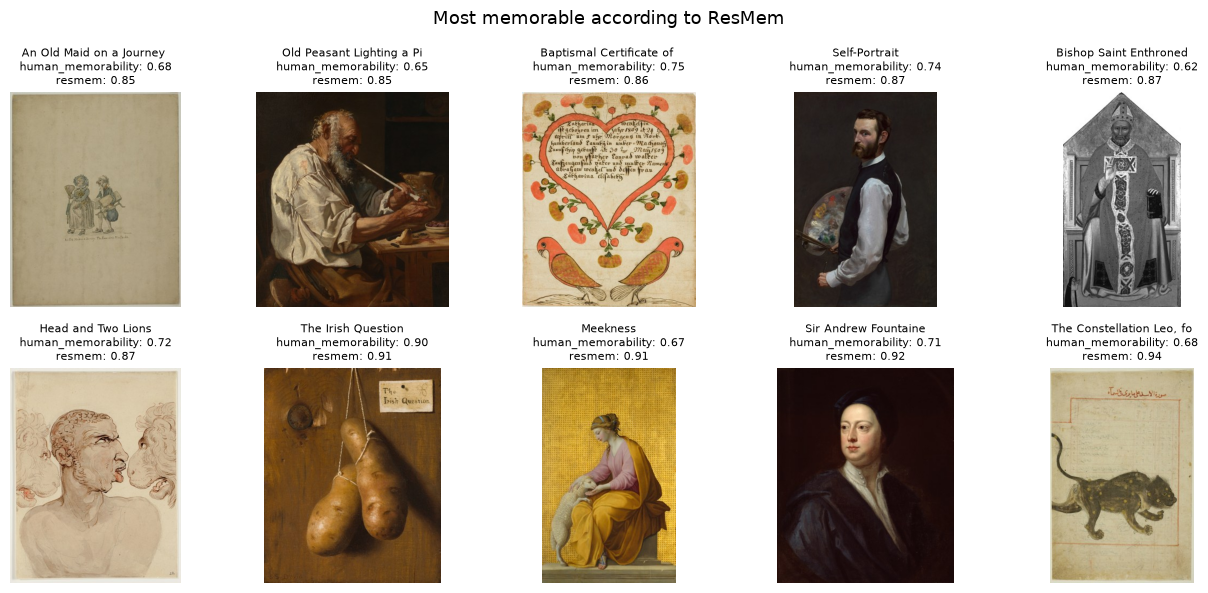

In [34]:
# Paintings ResMem predicts to be the MOST memorable
show_grid(data.nlargest(n_image, "resmem"), images, labels,
          title="Most memorable according to ResMem", sort_by="resmem")


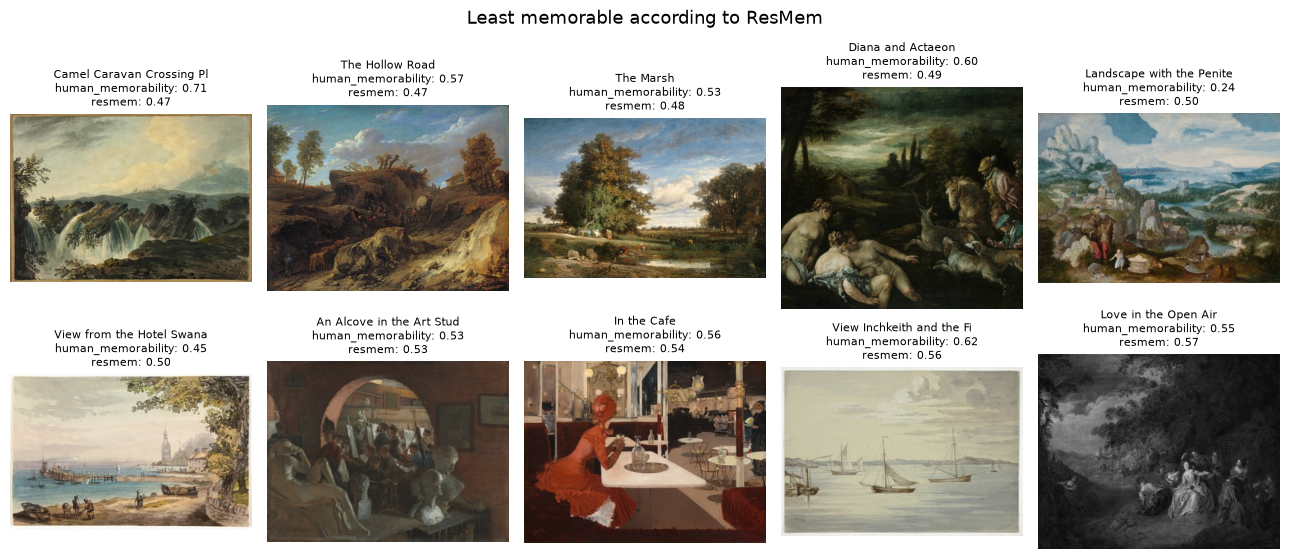

In [35]:
# Paintings ResMem predicts to be the LEAST memorable
show_grid(data.nsmallest(n_image, "resmem"), images, labels,
          title="Least memorable according to ResMem", sort_by="resmem")

## 5. The key result: does ResMem predict human memory?

We use a **Spearman correlation**, which only cares about the *ranking* of paintings. That is the usual choice for memorability scores.

In [36]:
rho, p = spearmanr(data["resmem"], data["human_memorability"])

# Very small p-values are reported as "p < 0.001" (standard convention)
if p < 0.001:
    p_text = "p < 0.001"
else:
    p_text = f"p = {p:.3f}"          # otherwise: 3 decimals, e.g. p = 0.042

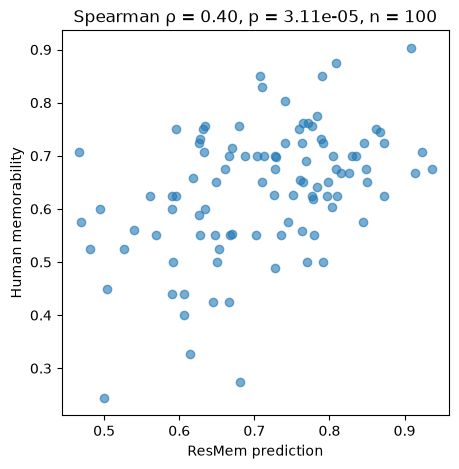

In [37]:
plt.figure(figsize=(5, 5))
plt.scatter(data["resmem"], data["human_memorability"], alpha=0.6)
plt.xlabel("ResMem prediction"); plt.ylabel("Human memorability")
plt.title(f"Spearman ρ = {rho:.2f}, p = {p:.3g}, n = {len(data)}")
plt.show()

**Think about it:**
- Is the correlation positive? How strong is it?
- Rerun sections 1–5 with a different `SEED`. How much does ρ change? What does that tell you about using only ~200 paintings?
- Rerun with more images. Did the results change?

## 6. Where do ResMem and humans disagree?
The most informative paintings are often the ones the model gets wrong.

In [38]:
# Convert both scores to ranks (0 = lowest, 1 = highest) so they are on the same scale
data["human_rank"] = data["human_memorability"].rank(pct=True)
data["resmem_rank"] = data["resmem"].rank(pct=True)

# Positive disagreement: ResMem ranks the painting higher than humans do
# Negative disagreement: humans rank it higher than ResMem does
data["disagreement"] = data["resmem_rank"] - data["human_rank"]

# Columns written under each painting
labels = ["title", "human_memorability", "resmem"]

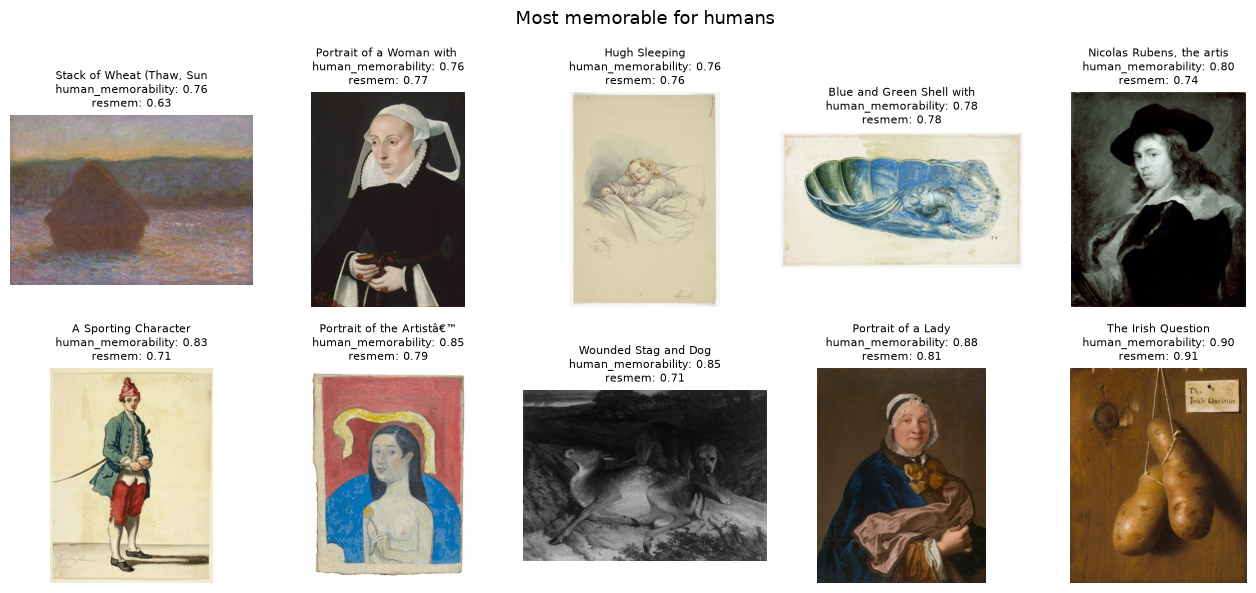

In [39]:
show_grid(data.nlargest(n_image, "human_memorability"), images, labels,
          title="Most memorable for humans", sort_by="human_memorability")

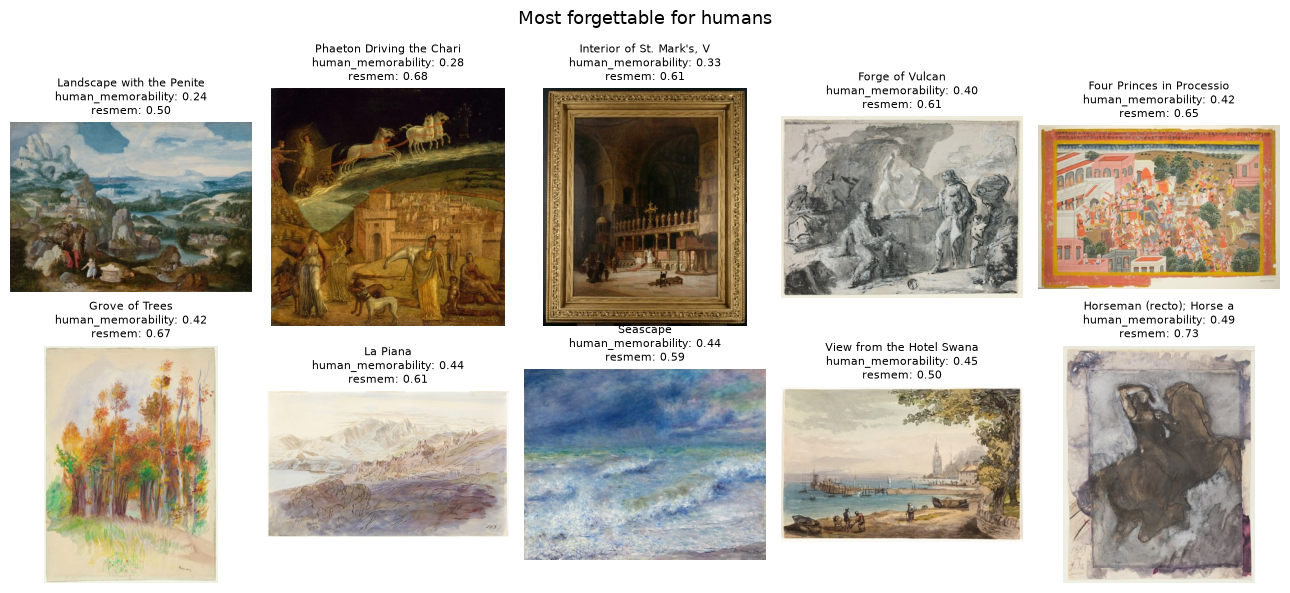

In [40]:
show_grid(data.nsmallest(n_image, "human_memorability"), images, labels,
          title="Most forgettable for humans", sort_by="human_memorability")

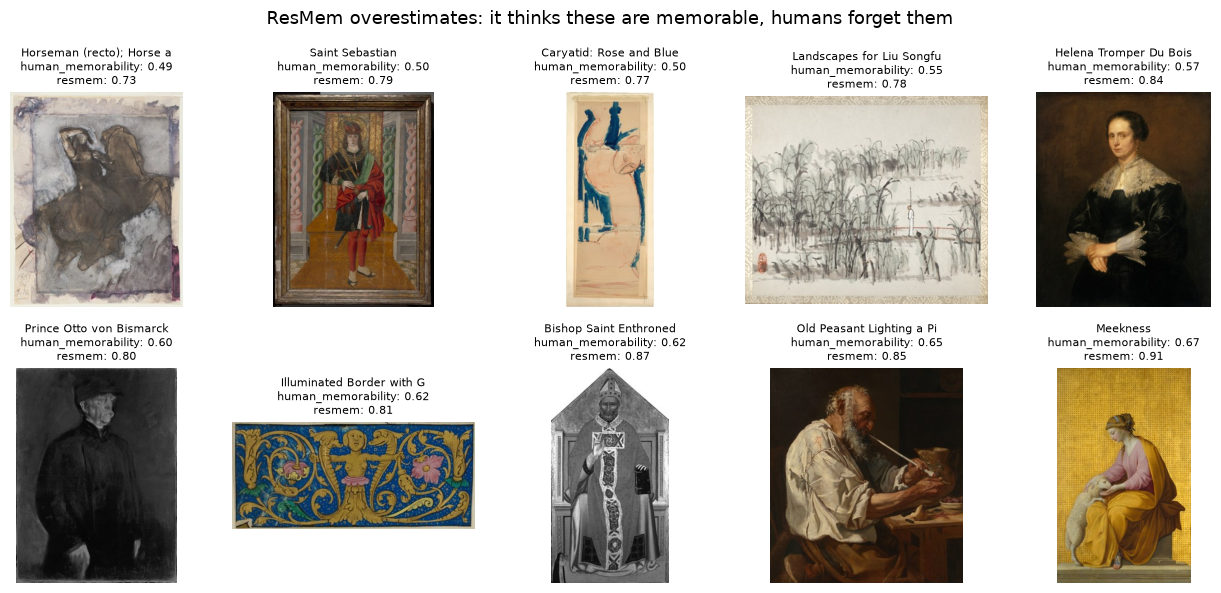

In [41]:
show_grid(data.nlargest(n_image, "disagreement"), images, labels,
          title="ResMem overestimates: it thinks these are memorable, humans forget them",
          sort_by="human_memorability")

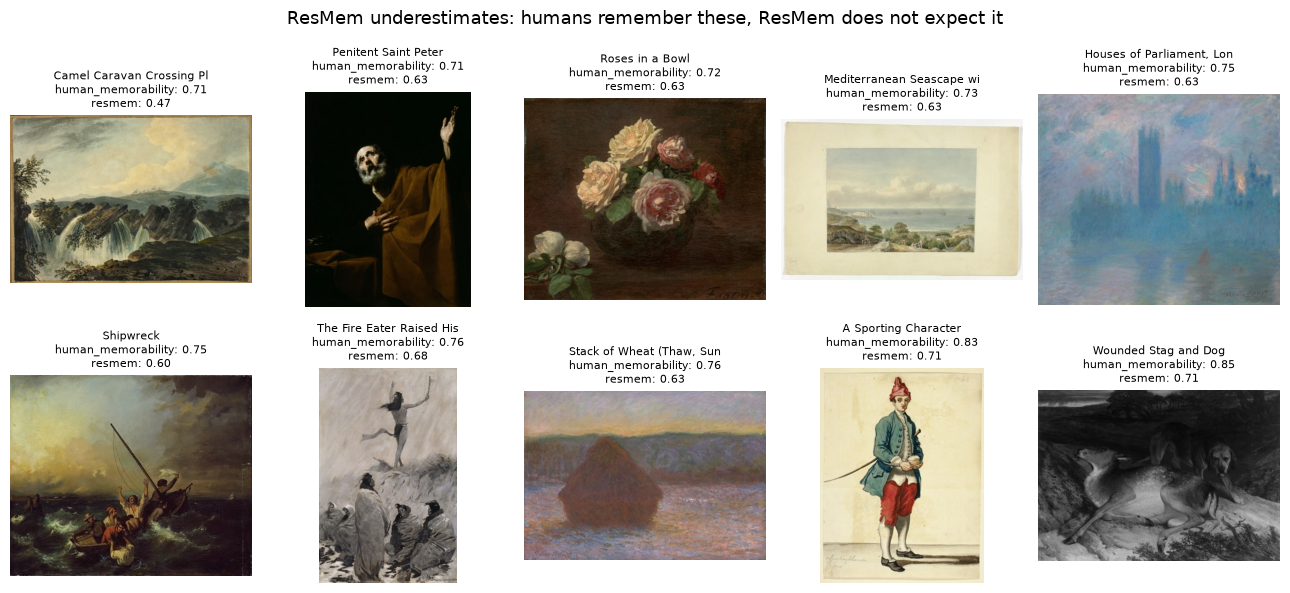

In [42]:
show_grid(data.nsmallest(n_image, "disagreement"), images, labels,
          title="ResMem underestimates: humans remember these, ResMem does not expect it",
          sort_by="human_memorability")

## 7. Discussion questions

1. Look at the paintings ResMem got wrong. Is there a pattern? What might humans use that ResMem does not have access to?
2. ResMem was trained on photographs of everyday scenes. Why does it work on paintings at all?
3. The paper found that ResMem could also predict which paintings are *famous*. How would you explain that? Does it mean fame is "just" visual?